In [64]:
import numpy as np
import pandas as pd
from skimage import io

from glob import glob
from os import path
from pathlib import Path
import seaborn as sb
import matplotlib.pyplot as plt

from functools import reduce
from twophotonUtils import parse_XML_timestamps
from skimage import draw


In [62]:
experiment_dirname= Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/NMS/Dermal topography/mTmG clones/05-29-2026 mTmG clone rep2/DOB 03-22-2026')

dx = 0.58 # microns per pixel
dz = 1


In [166]:
manifest = []
# Parse filestructure
mice_dirs = list(experiment_dirname.glob('*/'))
timestamps = {}

for m in mice_dirs:
    mouse = m.name
    for r in m.glob('*R*'):
        
        region = r.name
        timestamps[mouse+'_'+region] = parse_XML_timestamps(r)

        for c in r.glob('Clones/*.csv'):
            clone = path.splitext(path.split(c)[1])[0]
            manifest.append({'Mouse':mouse,'Region':region,
                             'dirname':r,'filename':c,'Clone':clone,
                            })
        
manifest = pd.DataFrame(manifest)
manifest['Mouse_Region'] = manifest['Mouse'] + '_' + manifest['Region']
manifest['Mouse_Region'].unique()


array(['F1 tail clip_R1', 'F1 tail clip_R3', 'F1 tail clip_R2',
       'M1 tail clip_R1', 'M1 tail clip_R2'], dtype=object)

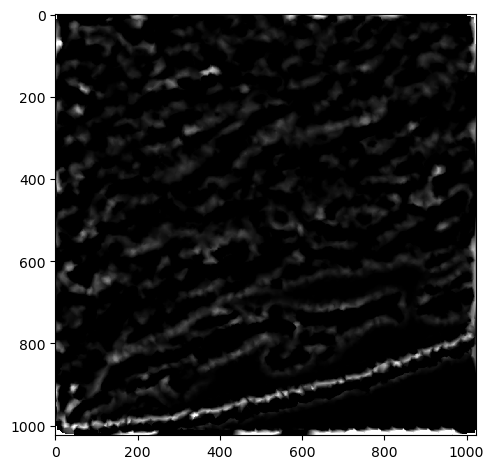

In [153]:
io.imshow(curvatures['F1 tail clip_R1'])

In [167]:
# Calculate the 'reference curvature'
from measurements import get_mesh_from_bm_image, get_tissue_curvature_over_grid
overwrite = True

curvatures = {}
for regionID,region in manifest.groupby(['Mouse_Region']):

    regionID = regionID[0]
    print(regionID)
    if (region.iloc[0]['dirname'] / '0. Day 0/reference_curvature.npz').exists() and not overwrite:
        curvatures[regionID] = np.load(region.iloc[0]['dirname'] /'0. Day 0/reference_curvature.npz')['reference_curvature'].T
        io.imsave(region.iloc[0]['dirname'] /'0. Day 0/reference_curvature.tif',curvatures[regionID])
        print('Saved')
    else:
        print((regionID, reference_frame))
        bm = io.imread(region.iloc[0]['dirname'] / '0. Day 0/height_image.tif')
        mesh = get_mesh_from_bm_image(bm,spacing=[dz,dx,dx],decimation_factor=60)
        meanC,gaussC = get_tissue_curvature_over_grid(mesh, bm.shape, spacing=[dz,dx,dx])
        # meanC = meanC.T
        curvatures[regionID] = meanC.T
        np.savez( region.iloc[0]['dirname'] / '0. Day 0/reference_curvature.npz',reference_curvature=meanC)
        io.imsave(region.iloc[0]['dirname'] /'0. Day 0/reference_curvature.tif',curvatures[regionID])

polys = {}
masks = {}
for regionID,region in manifest.groupby('Mouse_Region'):
    regionID = regionID
    polys[regionID] = pd.read_csv(path.join(region.iloc[0]['dirname'],'mask.csv'))
    masks[regionID] = draw.polygon2mask([1024,1024],polys[regionID][['axis-0','axis-1']]).T
# len(list(masks.keys()))

F1 tail clip_R1
('F1 tail clip_R1', 0)
F1 tail clip_R2
('F1 tail clip_R2', 0)
F1 tail clip_R3
('F1 tail clip_R3', 0)
M1 tail clip_R1
('M1 tail clip_R1', 0)
M1 tail clip_R2
('M1 tail clip_R2', 0)


In [154]:
# Load the clones .csvs

raw_clones = []
for idx,c in manifest.iterrows():
    data = pd.read_csv(c['filename'],index_col=0)
    data = data.rename(columns={'axis-0':'Frame','axis-1':'Z','axis-2':'Y','axis-3':'X'})
    raw_clones.append(data)

# Parse clone # and QC for clone physical distance (should be small)
clone_counts = []
for i,clone in enumerate(raw_clones):
    this_count = pd.merge(clone.groupby('Frame').mean()[['Z','Y','X']].reset_index(drop=True),
                          clone.groupby('Frame').count().reset_index()[['Frame','Z']].rename(columns={'Z':'Count'}),
                          left_index=True,right_index=True)
    this_count[['Mouse','Region','Clone','Mouse_Region']] = \
        manifest.iloc[i][['Mouse','Region','Clone','Mouse_Region']]
    refT = 0
    
    this_count['reference'] = refT
    clone_counts.append(this_count)

clone_counts = pd.concat(clone_counts,ignore_index=True)
clone_counts['UniqueID'] = clone_counts['Mouse'] + '_' + clone_counts['Region'] + '_' + clone_counts['Clone']


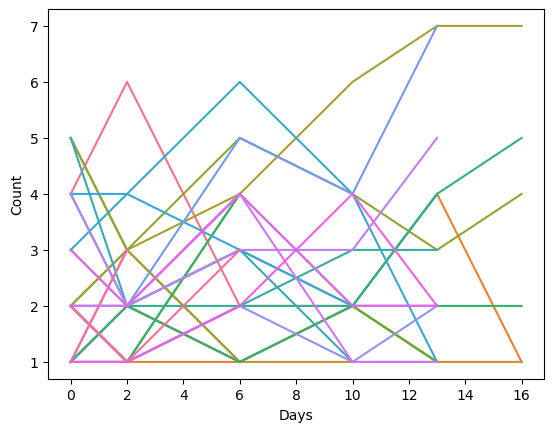

In [155]:
# Parse time stamps into delta times

# timestamps
df = []
for ID,clone in clone_counts.groupby('UniqueID'):
    ts = timestamps[clone.iloc[0]['Mouse_Region']]
    ts = [t - ts[0] for t in ts.values()]
    clone['Days'] = [ts[int(t)].days for t in clone['Frame']]
    df.append(clone)
    
df = pd.concat(df,ignore_index=True)

g = sb.lineplot(df,x='Days',y='Count',hue='UniqueID',legend=False)
# sb.move_legend(g,(0,1))

In [156]:
# Parse final clone size change from initial size
counted = []
for i,clone in df.groupby('UniqueID'):
    if len(clone) < 5:
        size_change = -clone.iloc[0]['Count']
    else:
        size_change = clone.iloc[-1]['Count'] - clone.iloc[0]['Count']
    clone['Initial size'] = clone.iloc[0]['Count']
    clone['Size change'] = clone['Count'] - clone.iloc[0]['Count']
    clone['Final size change'] = size_change
    clone['Extinction time'] = clone.iloc[-1]['Days']
    clone['UniqueID'] = i
    
    counted.append(clone)

df = pd.concat(counted,ignore_index=True)
df

,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time
0,58.0,891.776356,477.248461,0.0,4,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,0,4,0,-2,13
1,58.0,878.116925,484.186155,1.0,6,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,2,4,2,-2,13
2,46.0,912.508456,465.505670,2.0,2,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,6,4,-2,-2,13
3,49.0,894.205899,474.252024,3.0,2,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,10,4,-2,-2,13
4,51.0,874.607586,484.456105,4.0,2,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,13,4,-2,-2,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,29.0,534.847059,269.399636,0.0,2,M1 tail clip,R2,Clone8,M1 tail clip_R2,0,M1 tail clip_R2_Clone8,0,2,0,-2,2
140,34.0,538.530395,263.634414,1.0,1,M1 tail clip,R2,Clone8,M1 tail clip_R2,0,M1 tail clip_R2_Clone8,2,2,-1,-2,2
141,31.0,464.767777,218.014735,0.0,2,M1 tail clip,R2,Clone9,M1 tail clip_R2,0,M1 tail clip_R2_Clone9,0,2,0,-2,6
142,29.0,464.207654,206.812282,1.0,1,M1 tail clip,R2,Clone9,M1 tail clip_R2,0,M1 tail clip_R2_Clone9,2,2,-1,-2,6


In [157]:
# Load tissue curvatures

df_curv = []
for i,clone in df.groupby('UniqueID'):

    ref = int(clone.iloc[0]['reference'])
    
    if ref in clone.set_index('Frame').index:
        Y,X = (clone.set_index('Frame').loc[ref][['Y','X']]).astype(int)
        C = curvatures[clone.iloc[0]['Mouse_Region']].copy()
        mask = masks[clone.iloc[0]['Mouse_Region']]
        C[~mask] = np.nan
        initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
    else:
        initC = np.nan
        
    clone['Initial curvature'] = initC
    df_curv.append(clone)
    
df = pd.concat(df_curv,ignore_index=True)
df

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_34725/94434729.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_34725/94434729.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_34725/94434729.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_34725/94434729.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_34725/94434729.py:13: RuntimeWarning: Mean of empty slice
  initC = np.nanmean(C[Y-10:Y+10,X-10:X+10])


,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature
0,58.0,891.776356,477.248461,0.0,4,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,0,4,0,-2,13,0.000083
1,58.0,878.116925,484.186155,1.0,6,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,2,4,2,-2,13,0.000083
2,46.0,912.508456,465.505670,2.0,2,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,6,4,-2,-2,13,0.000083
3,49.0,894.205899,474.252024,3.0,2,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,10,4,-2,-2,13,0.000083
4,51.0,874.607586,484.456105,4.0,2,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,F1 tail clip_R1_Clone1,13,4,-2,-2,13,0.000083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,29.0,534.847059,269.399636,0.0,2,M1 tail clip,R2,Clone8,M1 tail clip_R2,0,M1 tail clip_R2_Clone8,0,2,0,-2,2,-0.014981
140,34.0,538.530395,263.634414,1.0,1,M1 tail clip,R2,Clone8,M1 tail clip_R2,0,M1 tail clip_R2_Clone8,2,2,-1,-2,2,-0.014981
141,31.0,464.767777,218.014735,0.0,2,M1 tail clip,R2,Clone9,M1 tail clip_R2,0,M1 tail clip_R2_Clone9,0,2,0,-2,6,-0.082924
142,29.0,464.207654,206.812282,1.0,1,M1 tail clip,R2,Clone9,M1 tail clip_R2,0,M1 tail clip_R2_Clone9,2,2,-1,-2,6,-0.082924


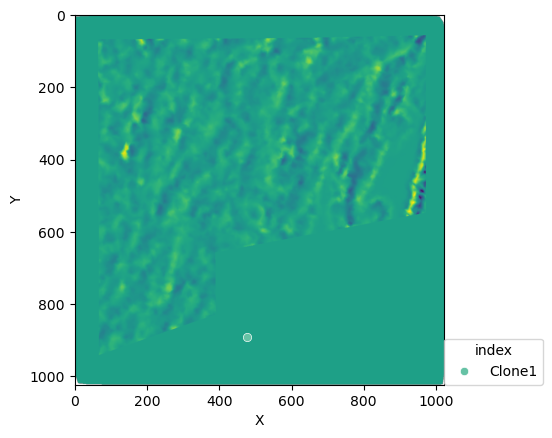

In [158]:
region = 'F1 tail clip_R1'
plt.imshow(curvatures[region].T*masks[region].T)

pd.DataFrame({ID:c[['X','Y']].mean() for ID,c in clone_counts.set_index('Mouse_Region').loc[region].groupby('Clone')}).T.reset_index()

g = sb.scatterplot( pd.DataFrame({ID:c.set_index('Frame').loc[0][['X','Y']]
                                  for ID,c in clone_counts.set_index('Mouse_Region').loc[region].groupby('Clone')}).T.reset_index().iloc[0:1],
              x='X',y='Y',hue='index',palette='Set2')
sb.move_legend(g,[1,0])

In [159]:
# pd.DataFrame([clone for _,clone in df.groupby('UniqueID')])
df_unique = pd.DataFrame([c.iloc[0] for _,c in df.groupby('UniqueID')])
df_unique.set_index('UniqueID')

,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature
UniqueID,,,,,,,,,,,,,,,,
F1 tail clip_R1_Clone1,58.0,891.776356,477.248461,0.0,4,F1 tail clip,R1,Clone1,F1 tail clip_R1,0,0,4,0,-2,13,0.000083
F1 tail clip_R1_Clone2,60.0,734.794633,782.339506,0.0,1,F1 tail clip,R1,Clone2,F1 tail clip_R1,0,0,1,0,-1,6,NaN
F1 tail clip_R1_Clone3,55.0,560.589633,676.173399,0.0,2,F1 tail clip,R1,Clone3,F1 tail clip_R1,0,0,2,0,-2,6,NaN
F1 tail clip_R1_Clone4,35.0,587.510963,385.343757,0.0,2,F1 tail clip,R1,Clone4,F1 tail clip_R1,0,0,2,0,-1,16,0.050052
F1 tail clip_R1_Clone5,47.0,410.085739,261.584358,0.0,2,F1 tail clip,R1,Clone5,F1 tail clip_R1,0,0,2,0,-1,16,0.009895
F1 tail clip_R1_Clone6,56.0,218.124822,723.768244,0.0,1,F1 tail clip,R1,Clone6,F1 tail clip_R1,0,0,1,0,-1,10,0.042963
F1 tail clip_R1_Clone7,51.0,372.909224,928.895171,0.0,2,F1 tail clip,R1,Clone7,F1 tail clip_R1,0,0,2,0,-2,0,NaN
F1 tail clip_R2_Clone1,44.0,860.144331,419.636065,0.0,1,F1 tail clip,R2,Clone1,F1 tail clip_R2,0,0,1,0,-1,2,NaN
F1 tail clip_R2_Clone2,48.0,158.769743,521.815488,0.0,5,F1 tail clip,R2,Clone2,F1 tail clip_R2,0,0,5,0,2,16,-0.013043


In [160]:
from basicUtils import nonan_pairs
from scipy.stats import pearsonr
X,Y = nonan_pairs(df_unique['Initial curvature'],df_unique['Final size change'])
R = pearsonr(X,Y)
print(len(X))
R

32


PearsonRResult(statistic=np.float64(0.15510277955178714), pvalue=np.float64(0.3966425303924662))

In [161]:
df_unique[df_unique['Initial curvature']> 0.8]

,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature


(-0.5, 0.5)

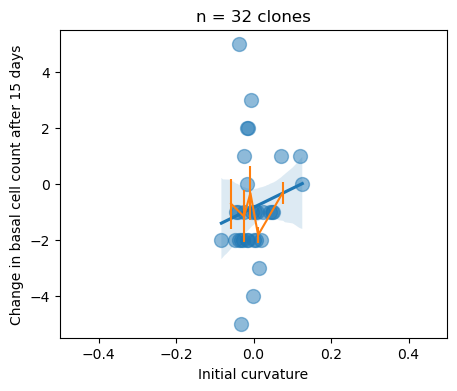

In [165]:
from basicUtils import plot_bin_means
unique = [c.iloc[0] for _,c in df.groupby('UniqueID')]
unique = pd.DataFrame(unique)

fig = plt.figure(figsize=[5,4])
plt.title(f'n = {len(df_unique.dropna())} clones')
sb.regplot(unique,x='Initial curvature',y='Final size change',y_jitter=0, scatter_kws={'alpha':0.5,'s':100})

plot_bin_means(unique['Initial curvature'],unique['Final size change'],bin_edges=6,mean='mean',minimum_n=5,bin_style='percentile')
plt.ylabel('Change in basal cell count after 15 days')
plt.xlim([-.5,.5])

# fig.savefig(path.join(experiment_dirname,'Figures/curvature_v_size_change.svg'))

In [163]:
df_unique[df_unique['Final size change'] > 2]

,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature
69,29.0,686.273795,126.766116,0.0,1,M1 tail clip,R1,Clone10,M1 tail clip_R1,0,M1 tail clip_R1_Clone10,0,1,0,3,13,-0.006281
104,36.0,561.949820,527.970211,0.0,2,M1 tail clip,R2,Clone1,M1 tail clip_R2,0,M1 tail clip_R2_Clone1,0,2,0,5,13,-0.038145


,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature
Concavity,,,,,,,,,,,,,,,,,
False,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,19
True,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13


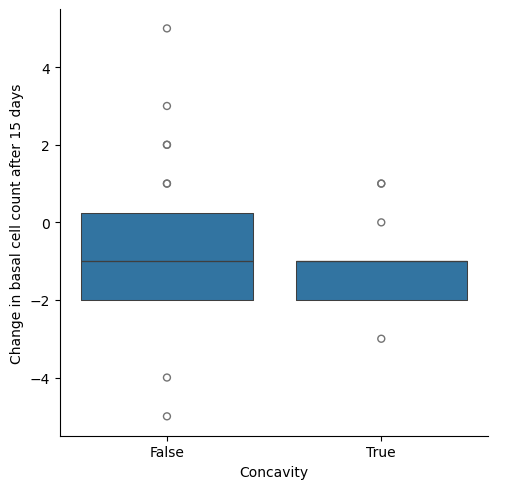

In [117]:
from basicUtils import ttest_from_groupby

df_unique['Concavity'] = df_unique['Initial curvature'] >= 0
sb.catplot(df_unique,x='Concavity',y='Final size change',kind='boxen')
plt.ylabel('Change in basal cell count after 15 days')

# plt.savefig(path.join(experiment_dirname,'Figures/convexity_v_size_change.svg'))
ttest_from_groupby(df_unique,field2group='Concavity',field2test='Final size change')
df_unique.groupby('Concavity').count()

In [118]:
df = pd.merge(df,df_unique[['Concavity','UniqueID']],left_on='UniqueID',right_on='UniqueID')


Text(0, 0.5, 'Median clone size change')

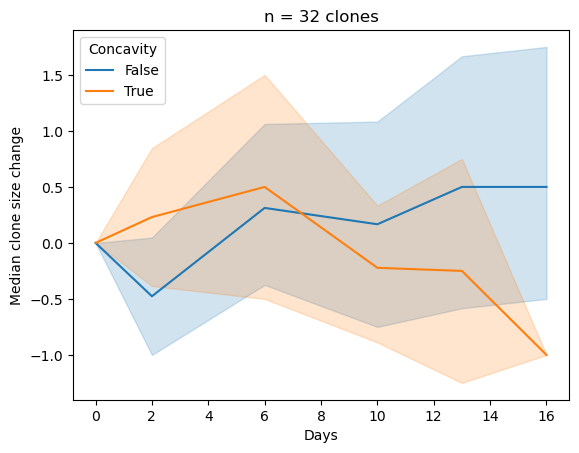

In [119]:
plt.title(f'n = {len(df_unique.dropna())} clones')
g = sb.lineplot(df,x='Days',y='Size change',hue='Concavity')
plt.ylabel('Median clone size change')

# plt.savefig(path.join(experiment_dirname,'Figures/curvature_v_size_change_timeseries.svg'))

,Z,Y,X,Frame,Count,Mouse,Region,Clone,Mouse_Region,reference,UniqueID,Days,Initial size,Size change,Final size change,Extinction time,Initial curvature,Concavity
0,58.0,767.901095,445.712444,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone1,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone1,0,1,0,-1,3,1.016346e-02,True
2,55.0,528.149487,959.598983,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone10,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone10,0,1,0,0,14,-4.420355e-01,False
7,51.0,773.942356,347.663333,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone11,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone11,0,1,0,-1,0,-2.364859e-02,False
10,59.0,143.443798,689.456556,0.0,1,F1 DOB 12-5-2025,Left paw R1,Clone13,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone13,0,1,0,2,14,3.474013e-08,True
19,59.0,827.726097,596.548168,0.0,2,F1 DOB 12-5-2025,Left paw R1,Clone2,F1 DOB 12-5-2025_Left paw R1,0,F1 DOB 12-5-2025_Left paw R1_Clone2,0,2,0,-2,6,-2.378876e-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,56.0,297.119817,490.820783,0.0,2,M2 DPB 12-5-2025,Left paw R2,Clone4,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone4,0,2,0,2,14,3.249429e-01,True
396,61.0,712.193860,531.039177,0.0,2,M2 DPB 12-5-2025,Left paw R2,Clone5,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone5,0,2,0,0,14,-1.660713e-01,False
401,64.0,321.554240,872.827160,0.0,1,M2 DPB 12-5-2025,Left paw R2,Clone6,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone6,0,1,0,-1,0,1.611067e-01,True
402,59.0,356.642388,616.315095,0.0,6,M2 DPB 12-5-2025,Left paw R2,Clone7,M2 DPB 12-5-2025_Left paw R2,0,M2 DPB 12-5-2025_Left paw R2_Clone7,0,6,0,-6,10,-1.892009e-01,False
